In [366]:
import numpy as np
import matplotlib.pyplot as plt

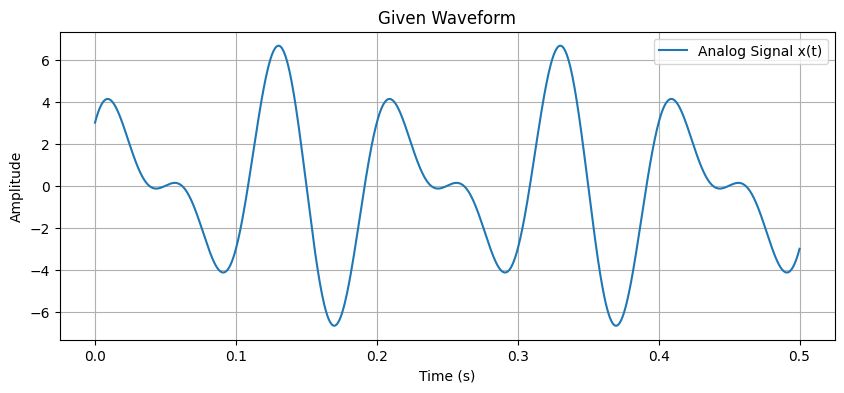

In [367]:
# Task 01

t=np.linspace(0,0.5,1000)
f=[10,15]
# x_t=3*np.sin(2*np.pi*f[0]*t)+4*np.sin(2*np.pi*f[1]*t)
x_t=4*np.sin(2*np.pi*f[0]*t)+3*np.cos(2*np.pi*f[1]*t)

plt.figure(figsize=(10, 4))
plt.plot(t, x_t, label='Analog Signal x(t)')
plt.title(f'Given Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()




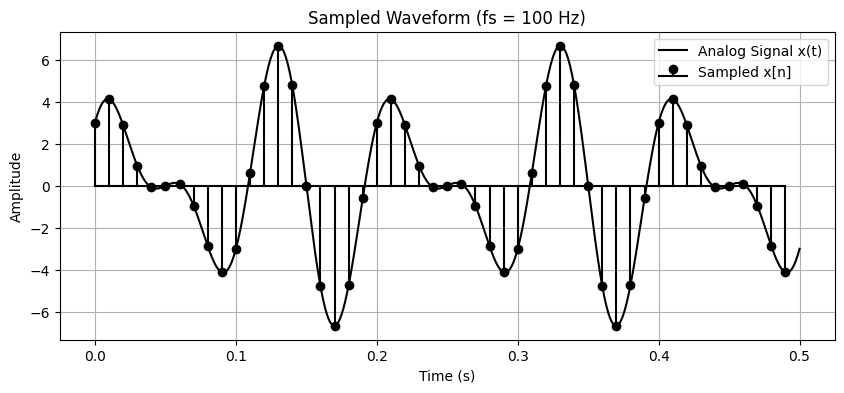

In [368]:

#sampling
Fs=100 # Fs>F
Ts=1/Fs
sample_time=np.arange(0,0.5,Ts)

xt_sample=(4*np.sin(2*np.pi*f[0]*sample_time)+3*np.cos(2*np.pi*f[1]*sample_time))

plt.figure(figsize=(10, 4))
plt.stem(sample_time,xt_sample,linefmt='black', markerfmt='black', basefmt='black', label='Sampled x[n]')
plt.plot(t,x_t,'black',label='Analog Signal x(t)')
plt.title(f'Sampled Waveform (fs = {Fs} Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


-7.0
-5.25
-3.5
-1.75
0.0
1.75
3.5
5.25
7.0


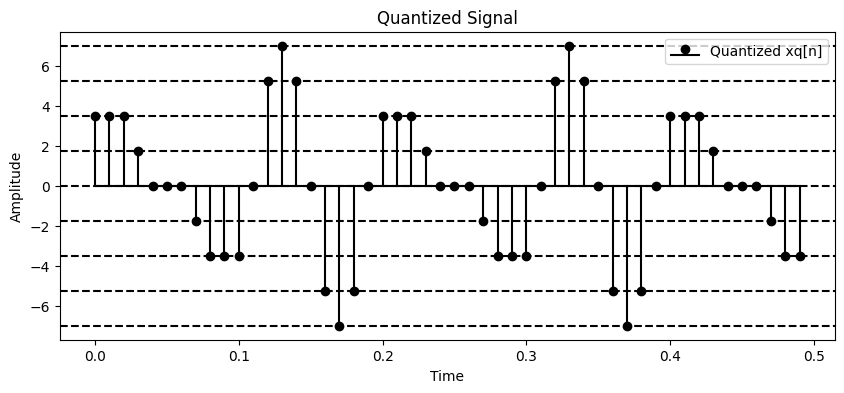

In [369]:
xmin=-7
xmax=7


level=8
quantization_step=(xmax-xmin)/(level)

quantized_signal=[]

for i in xt_sample:
    value=round(i/quantization_step)*quantization_step
    quantized_signal.append(value)
quantized_signal=np.array(quantized_signal)


plt.figure(figsize=(10,4))
# plt.step(sample_time, quantized_signal, where='post', color='red', linewidth=2, label='Staircase Signal')

plt.title(f'Quantized Signal')
plt.stem(sample_time,quantized_signal,linefmt='black', markerfmt='black', basefmt='black', label='Quantized xq[n]')

for label_value in np.arange(xmin, xmax + quantization_step, quantization_step):
    plt.axhline(y=label_value, color='black', linestyle='--')
    print(label_value)

plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


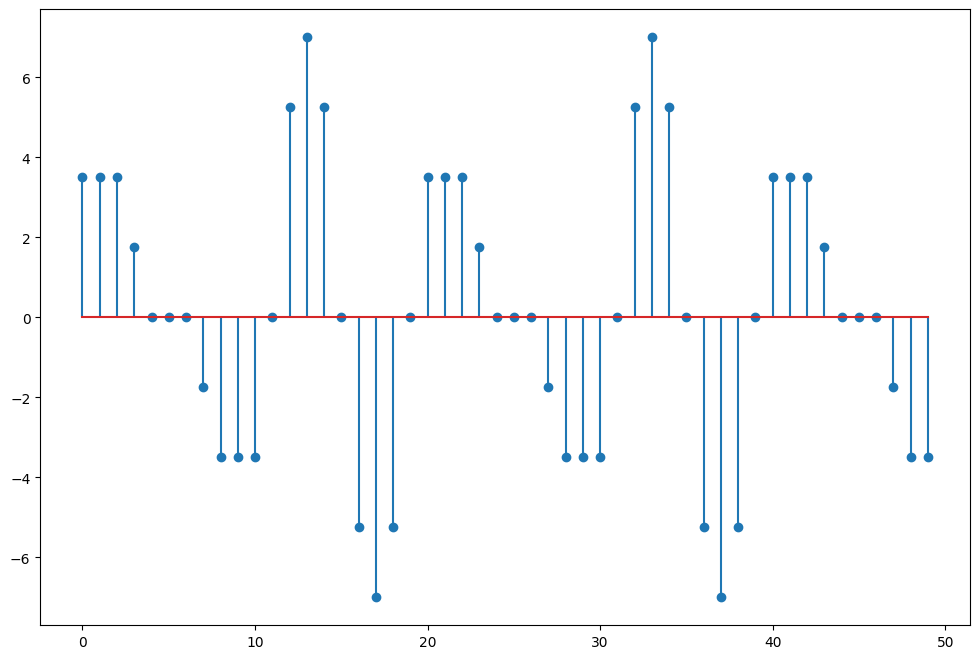

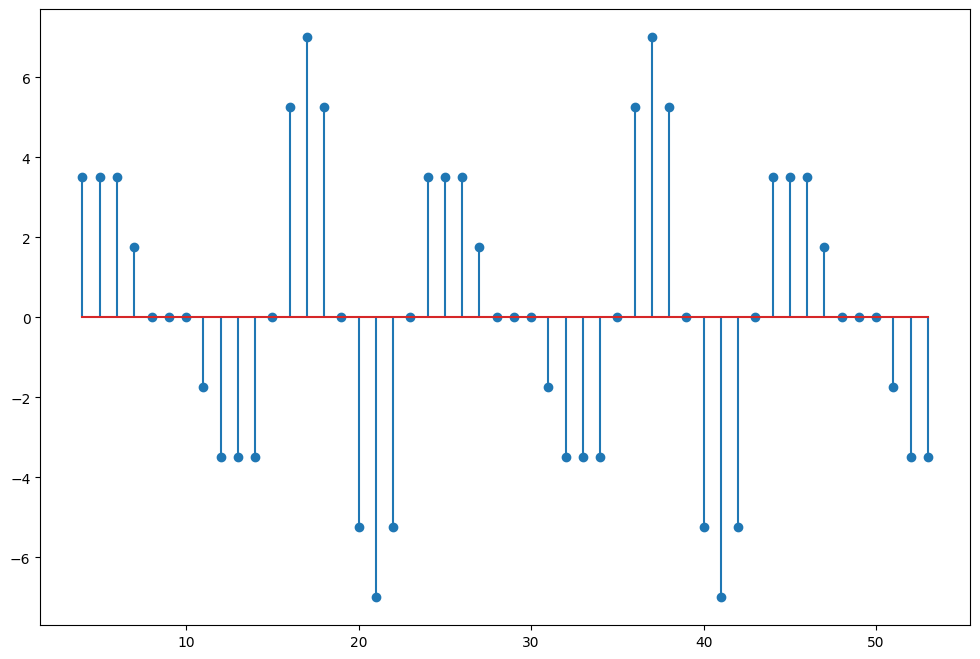

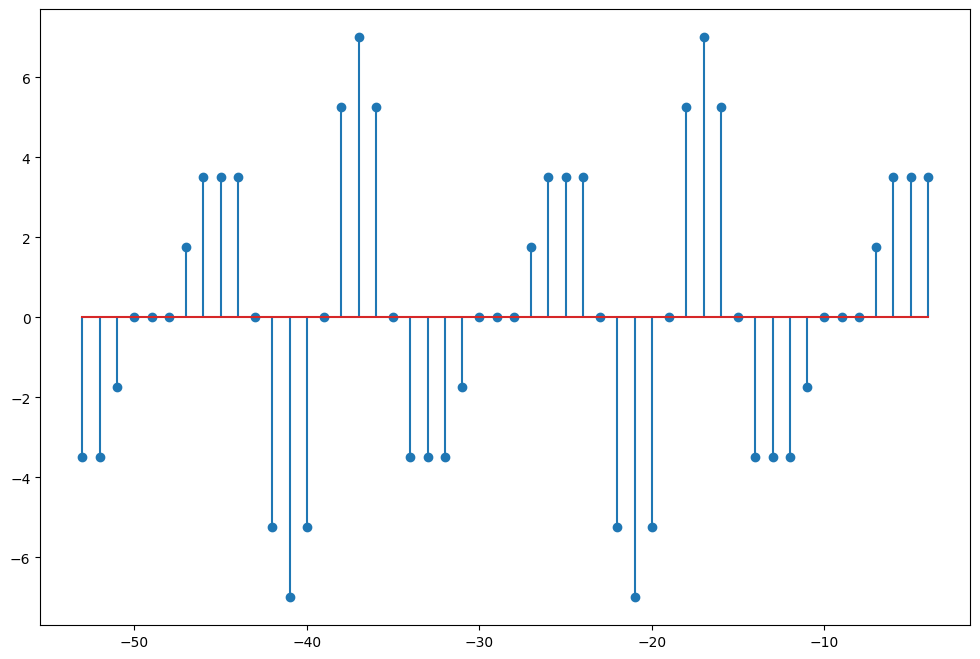

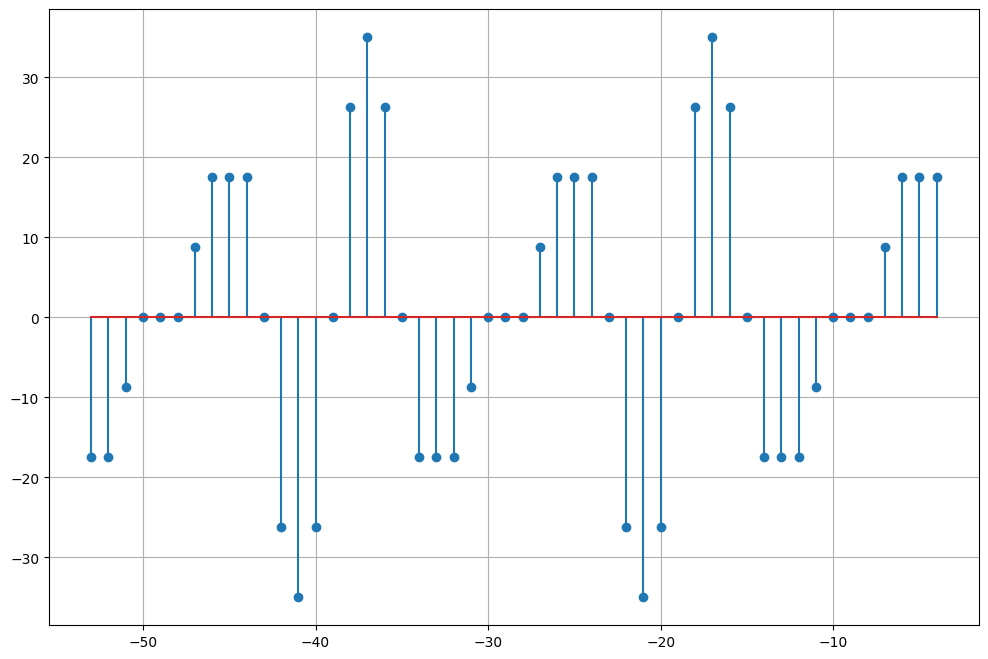

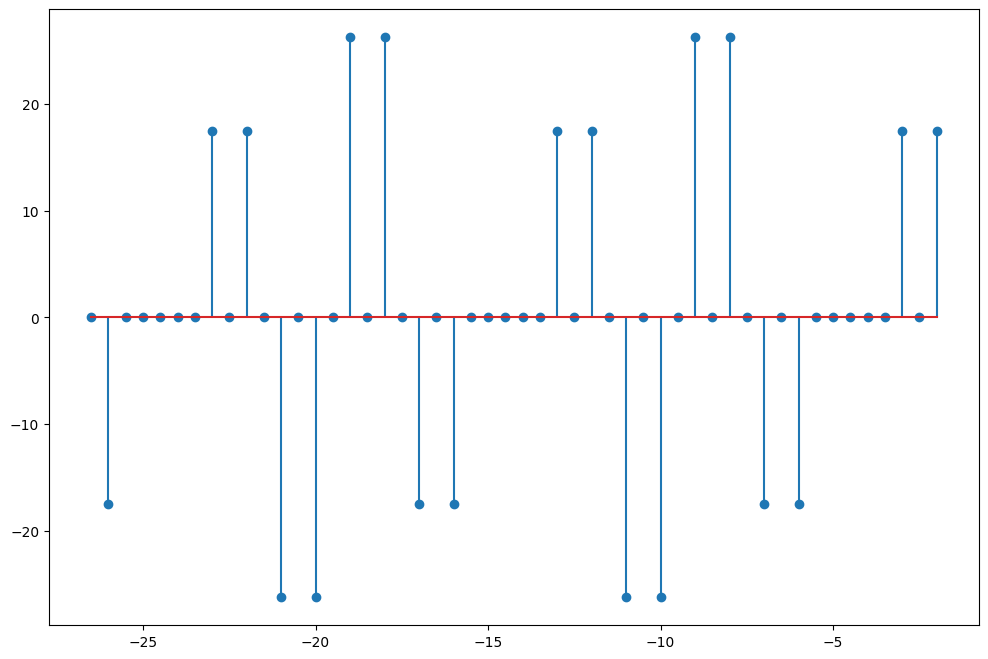

In [370]:
# Task 02


n=np.array([i for i in range(len(quantized_signal))])
signal=np.array(quantized_signal)


# Original Signal
plt.figure(figsize=(12,8))
plt.stem(n,signal)
plt.show()


# Shifting:

k=4
modulated=n+k
plt.figure(figsize=(12,8))
plt.stem(modulated,signal)
plt.show()


# Reversal

modulated=-modulated
# print(modulated)
plt.figure(figsize=(12,8))
plt.stem(modulated,signal)
plt.show()


# Amplitude Scaling:
A=5
signal=A*signal
plt.figure(figsize=(12,8))
plt.stem(modulated,signal)
plt.grid(True)
plt.show()

# Time Scaling:
T=2
def new_signal(x,y):
    for i in range(len(x)):
        if round(x[i])!=x[i]:
            y[i]=0
    return y
modulated=modulated/T
signal=new_signal(modulated,signal)
plt.figure(figsize=(12,8))
plt.stem(modulated,signal)
plt.show()





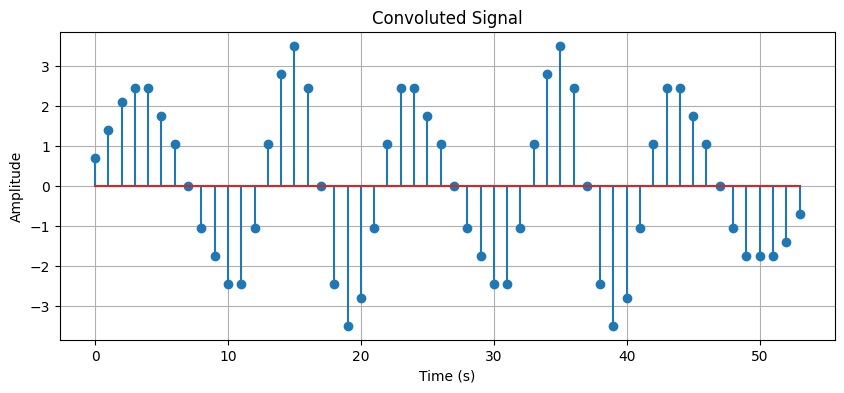

In [371]:
# Task 03
x_n=quantized_signal
# h_n=[2,-1,0,-1,5]
h_n=np.array([1,1,1,1,1])/5

convolved=np.convolve(x_n,h_n)

plt.figure(figsize=(10, 4))
plt.title(f'Convoluted Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.stem(convolved)
plt.show()


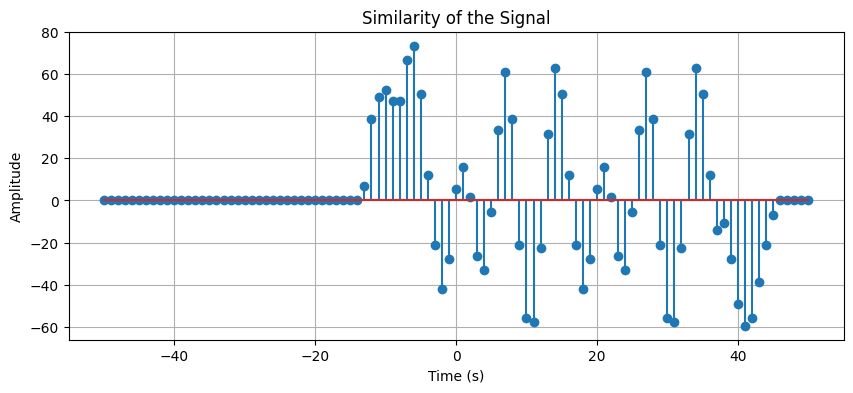

delay: -6
max_value: 73.5


In [372]:
# Task 04
def correlation(x,x0,y,y0):
    t=[]
    rxy=[]
    mxx=-100000
    a=len(x)
    b=len(y)
    mx=0
    if a>b:
        mx=a
    else:
        mx=b
    for n in range(-mx,mx+1):
        rxy.append(0)
        t.append(n)
        for k in range(-mx,mx+1):
            try:                       # if positive index exist?
                if k>=(-x0): a=x[k+x0] # if negative index exists?
                else: a=0
            except: a=0
            
            try:    
                if (k-n)>=(-y0): b=y[k+y0-n]
                else: b=0
            except: b=0
            
            rxy[-1]+=a*b
        
        if mxx<=abs(rxy[-1]):
            delay=t[-1]
            mxx=abs(rxy[-1])
        
    return t,rxy,(delay,mxx)

x_n=list(quantized_signal)
# filtered=convolved
filtered=[0, 0, 0, 0, 2, 4, 6, 8, 6, 4, 2, 3,9,2, 0, 0]

t,similarity,(delay,mx)=correlation(x_n,0,filtered,0)

plt.figure(figsize=(10,4))
plt.title(f'Similarity of the Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.stem(t,similarity)
plt.show()
print(f"delay: {delay}")
print(f"max_value: {mx}")

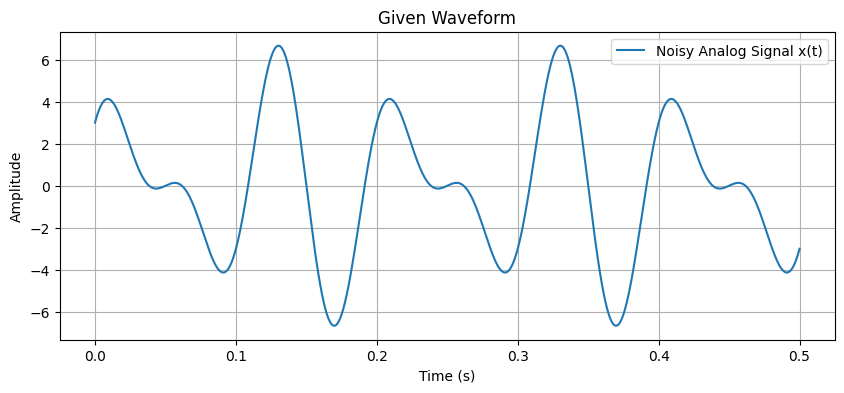

In [373]:
t=np.linspace(0,0.5,1000)
f=[10,15]
# x_t=3*np.sin(2*np.pi*f[0]*t)+4*np.sin(2*np.pi*f[1]*t)
x_t=4*np.sin(2*np.pi*f[0]*t)+3*np.cos(2*np.pi*f[1]*t)


plt.figure(figsize=(10, 4))
plt.plot(t, x_t, label='Noisy Analog Signal x(t)')
plt.title(f'Given Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

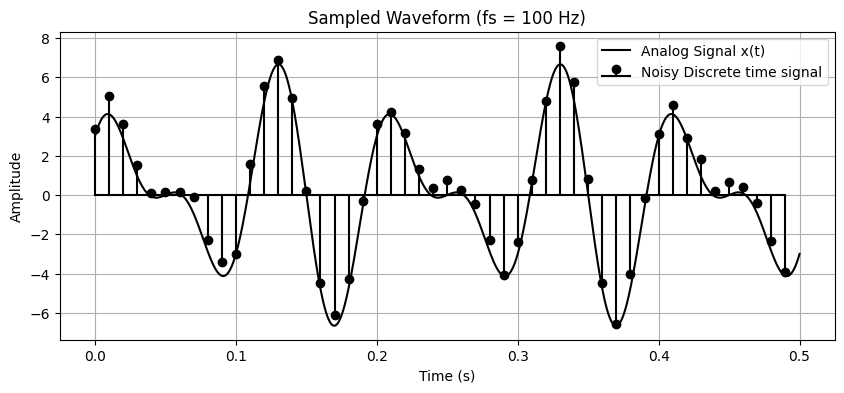

In [374]:

#sampling
Fs=100 # Fs>F
Ts=1/Fs
sample_time=np.arange(0,0.5,Ts)

xt_sample=(4*np.sin(2*np.pi*f[0]*sample_time)+3*np.cos(2*np.pi*f[1]*sample_time))

noise=np.random.random(len(xt_sample))

xt_sample=xt_sample+noise

plt.figure(figsize=(10, 4))
plt.stem(sample_time,xt_sample,linefmt='black', markerfmt='black', basefmt='black', label='Noisy Discrete time signal')
plt.plot(t,x_t,'black',label='Analog Signal x(t)')
plt.title(f'Sampled Waveform (fs = {Fs} Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

Manual DFT Calculation complete for N=50 samples.
Time taken: 0.0064 seconds


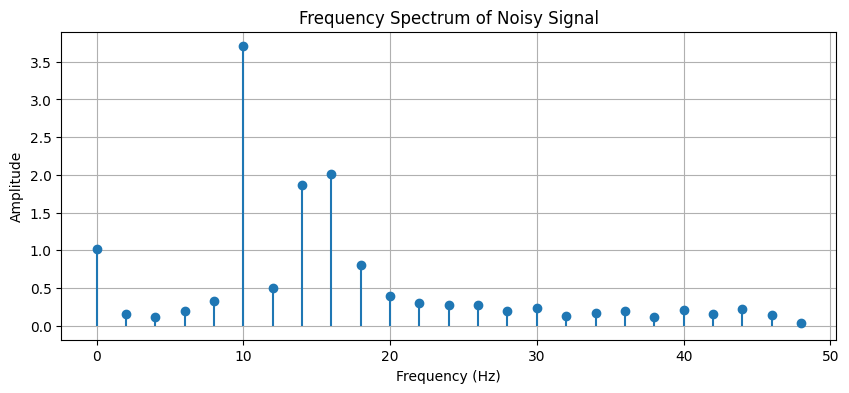

In [375]:
# import numpy as np
# import matplotlib.pyplot as plt
import time

# # --- 1. Signal Generation (Same as before) ---
# fs = 100              # Sampling frequency (Hz)
# duration = 1.0        # Duration (seconds)
# N = int(fs * duration) # Total samples (100)
# n = np.arange(N)      # Indices 0 to 99
# t = n / fs            # Time vector

# # The Signal: x[n] + Noise
# x_clean = 4 * np.sin(0.2 * np.pi * n) + 3 * np.cos(0.3 * np.pi * n)
np.random.seed(42)
# noise = 2.5 * np.random.randn(N)
y_n = xt_sample
n=len(xt_sample)
N=n

# --- 2. THE MANUAL DFT FUNCTION ---
def manual_dft(signal):
    """
    Computes the Discrete Fourier Transform (DFT) using the summation formula.
    Input: signal x[n]
    Output: complex spectrum X[k]
    """
    N = len(signal)
    X_k = np.zeros(N, dtype=complex) # Array to store the result
    
    # Outer Loop: Iterate through every frequency bin 'k'
    for k in range(N):
        current_Xk = 0 + 0j
        
        # Inner Loop: Summation over all time samples 'n'
        for n_idx in range(N):
            # The Formula: x[n] * e^(-j * 2*pi * k * n / N)
            exponent = -1j * 2 * np.pi * k * n_idx / N
            current_Xk += signal[n_idx] * np.exp(exponent)
            
        X_k[k] = current_Xk
        
    return X_k

# --- 3. Run the Manual Calculation ---
start_time = time.time()
X_manual = manual_dft(y_n)
end_time = time.time()

print(f"Manual DFT Calculation complete for N={N} samples.")
print(f"Time taken: {end_time - start_time:.4f} seconds")

# --- 4. Process for Plotting ---
# Calculate Magnitude |X[k]|
# We normalize by 2/N to get true amplitude
magnitude = (2/N) * np.abs(X_manual)

# Frequency Axis (0 to fs)
freqs = np.arange(N) * (100 / N)

# We only need the first half (0 to Nyquist)
half_N = N // 2
freqs_half = freqs[:half_N]
magnitude_half = magnitude[:half_N]

# --- 5. Plotting ---
plt.figure(figsize=(10, 4))
plt.stem(freqs_half, magnitude_half, basefmt=" ")
plt.title("Frequency Spectrum of Noisy Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()